### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [5]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000235EBF777C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000235EBF776D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("llama-3.1-8b-instant", model_provider="groq")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000235EC0E56C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000235EC0E5D20>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

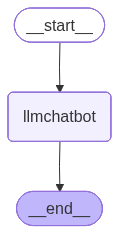

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

In [11]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [12]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings in the same way humans do, but I'm here and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going?


### Chatbot With Tool

In [13]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [14]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [15]:
tools=[tool,multiply]

In [16]:
llm_with_tool=llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000235EC0E56C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000235EC0E5D20>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

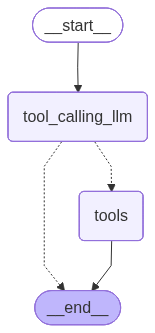

In [18]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [19]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [20]:
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-05-06/u-s-china-ai-gap-has-closed-and-silicon-valley-is-starting-to-notice", "title": "The U.S.-China AI gap has closed—and Silicon Valley is starting to notice - Los Angeles Times", "score": 0.6929958, "published_date": "Wed, 06 May 2026 13:49:06 GMT", "content": "A recent report by Stanford University’s Institute for Human-Centered AI says the U.S.-China gap in top AI models’ performance has “effectively closed.”\\n\\nU.S. policymakers and top AI firms including Anthropic and OpenAI have accused Chinese AI startups of stealing U.S. AI technologies. China says such allegations are groundless.\\n\\nLian Jye Su, a chief analyst at the research and advisory group Omdia, believes any AI gap between the U.S. and China will continue to narrow, despite U.S. export controls and China’s Great Firewall, the ruling Communist Party’s massive inte

In [21]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (t2z4gr6k7)
 Call ID: t2z4gr6k7
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.latimes.com/business/story/2026-05-06/u-s-china-ai-gap-has-closed-and-silicon-valley-is-starting-to-notice", "title": "The U.S.-China AI gap has closed—and Silicon Valley is starting to notice - Los Angeles Times", "score": 0.6929958, "published_date": "Wed, 06 May 2026 13:49:06 GMT", "content": "A recent report by Stanford University’s Institute for Human-Centered AI says the U.S.-China gap in top AI models’ performance has 

In [22]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (jez528w6j)
 Call ID: jez528w6j
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [23]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fxmagnvgk)
 Call ID: fxmagnvgk
  Args:
    query: recent ai news
    start_date: 2024-01-01
    time_range: day
    topic: news
  multiply (8xfgzrb38)
 Call ID: 8xfgzrb38
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================= Tool Message =================================
Name: multiply

50


### ReAct Agent Architecture

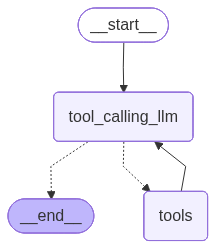

In [24]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qzbzwvwtb)
 Call ID: qzbzwvwtb
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (dz0arzvvs)
 Call ID: dz0arzvvs
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/06/02/palo-alto-ceo-customer-meeting-requests-surged-ai-security-concerns.html", "title": "Palo Alto CEO says customer meeting requests have surged amid AI security concerns - CNBC", "score": 0.59824234, "published_date": "Tue, 02 Jun 2026 22:55:23 GMT", "content": "* Palo Alto Networks CEO Nikesh Arora said artificial intelligence is increasing 

## Adding Memory In Agentic Graph

In [26]:
response=graph.invoke({"messages":"Hello my name is KRish"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Nice to meet you, KRish. How are you today?


In [27]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have information about your name.


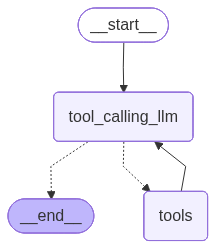

In [28]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is soujanya"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is soujanya', additional_kwargs={}, response_metadata={}, id='a880dc81-0d1a-49be-9ce3-54b4dd8b0540'),
  AIMessage(content="Hello Soujanya, it's nice to meet you. Is there anything I can help you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1752, 'total_tokens': 1775, 'completion_time': 0.043827395, 'completion_tokens_details': None, 'prompt_time': 0.374496311, 'prompt_tokens_details': None, 'queue_time': 0.390494847, 'total_time': 0.418323706}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8c6c-42b5-7d53-a523-95c9d656fa6b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 23, 'total_tokens': 1775})]}

In [30]:
response['messages'][-1].content

"Hello Soujanya, it's nice to meet you. Is there anything I can help you with today?"

In [31]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=tavily_search>{"query": "my name"}'}}

In [ ]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Your name is Soujanya.


### Streaming

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [ ]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

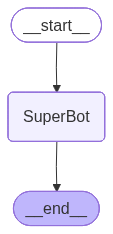

In [ ]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1542efc8-78a0-47d4-adde-39937cb14567'),
  AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, isn't it? Do you have a favorite team or player? Are you an avid fan of the Indian cricket team, considering your name is quite popular in India?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.078349593, 'completion_tokens_details': None, 'prompt_time': 0.007563395, 'prompt_tokens_details': None, 'queue_time': 0.099365764, 'total_time': 0.085912988}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8c38-aa37-7802-9730-ba0e62927cc5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'out

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish, nice to meet you. Cricket is a fantastic sport, and I'm sure you have a lot of enthusiasm for it. Which team or player is your favorite in international cricket, or perhaps you have a favorite domestic league like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.107330653, 'completion_tokens_details': None, 'prompt_time': 0.004236916, 'prompt_tokens_details': None, 'queue_time': 0.170755832, 'total_time': 0.111567569}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8c38-ab67-72f0-b38b-17bb33350e84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 56, 'total_tokens': 101})]}}


In [ ]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='5b9fdfe1-04f2-4b75-8051-18073ec38a19'), AIMessage(content="Hello Krish, nice to meet you. Cricket is a fantastic sport, and I'm sure you have a lot of enthusiasm for it. Which team or player is your favorite in international cricket, or perhaps you have a favorite domestic league like the Indian Premier League (IPL)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.107330653, 'completion_tokens_details': None, 'prompt_time': 0.004236916, 'prompt_tokens_details': None, 'queue_time': 0.170755832, 'total_time': 0.111567569}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8c38-ab67-72f0-b38b-17bb33350e84-0', tool_calls=[], inval

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, isn't it? There's something about the thrill of watching batsmen smash sixes, the skill of bowlers taking wickets, and the excitement of a close match that really gets the adrenaline pumping.\n\nAre you a fan of any particular team or player? Do you play cricket yourself, or do you just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 45, 'total_tokens': 125, 'completion_time': 0.406809383, 'completion_tokens_details': None, 'prompt_time': 0.057546389, 'prompt_tokens_details': None, 'queue_time': 0.170848961, 'total_time': 0.464355772}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8c38-b761-7d71-8950-f26c21c62b9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i

In [ ]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1a44511e-1b56-4b16-8394-8afa0dcc50cd'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, isn't it? There's something about the thrill of watching batsmen smash sixes, the skill of bowlers taking wickets, and the excitement of a close match that really gets the adrenaline pumping.\n\nAre you a fan of any particular team or player? Do you play cricket yourself, or do you just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 45, 'total_tokens': 125, 'completion_time': 0.406809383, 'completion_tokens_details': None, 'prompt_time': 0.057546389, 'prompt_tokens_details': None, 'queue_time': 0.170848961, 'total_time': 0.464355772}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None

In [ ]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e8c38-c593-7303-b851-06836cea5bc5', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='e1884722-3f00-4cfd-aef9-41bb823da3e9')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019e8c38-c59a-7f02-be90-0ea761bcb4db', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:d67772c9-190f-8c93-a992-9635bf1f3268'}, 'parent_ids': ['019e8c38-c593-7303-b851-06836cea5bc5']}
{'event': 'on_chain_stream', 'run_id': '019e8c38-c59a-7f02-be90